In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, beta as beta_dist, entropy
import statsmodels.api as sm

# ========== Section 1: Data Loading and Normalization for First Price Auction ==========

def load_and_clean_first_price_data(filepath):
    data = pd.read_csv(filepath)
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_fp'] >= 0) &
                        (data['bid_fp'] <= data['value_fp']) &
                        (data['value_fp'] <= 30) &
                        (data['value_fp'] >= 0)].copy()
    cleaned_data['bid_fp'] = cleaned_data['bid_fp'] / 30  # Normalize to 0-1 range
    cleaned_data['value_fp'] = cleaned_data['value_fp'] / 30  # Normalize to 0-1 range
    return cleaned_data

# ========== Section 2: Q-Learning Agent with Fixed Valuation ==========

class QLearningAgent:
    def __init__(self, valuation, action_min=0, action_max=1, granularity=21, epsilon=0.1, alpha=0.1):
        self.valuation = valuation  # Fixed valuation
        self.actions = np.linspace(action_min, action_max, granularity)  # Discretized bids in [0,1]
        self.epsilon = epsilon  # Exploration rate
        self.alpha = alpha  # Learning rate
        self.q_values = np.zeros(len(self.actions))  # Initialize Q-values

    def choose_action(self):
        """Select a bid using epsilon-greedy policy"""
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)  # Explore
        else:
            return self.actions[np.argmax(self.q_values)]  # Exploit

    def update_q_values(self, action, reward):
        """Update Q-values based on reward"""
        action_index = np.where(self.actions == action)[0][0]
        self.q_values[action_index] += self.alpha * (reward - self.q_values[action_index])

# ========== Section 3: Auction Simulation ==========

class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule

    def run_auction(self):
        """Run a full set of pairings in one round"""
        for i in range(len(self.agents)):
            for j in range(i+1, len(self.agents)):
                bid_i = max(self.price_floor, min(self.agents[i].choose_action(), self.price_ceiling))
                bid_j = max(self.price_floor, min(self.agents[j].choose_action(), self.price_ceiling))
                
                winner_idx, payment = self.payment_rule([bid_i, bid_j])
                
                if winner_idx == 0:
                    payoff_i = self.agents[i].valuation - payment
                    reward_i = payoff_i if payoff_i >= 0 else 0
                    self.agents[i].update_q_values(bid_i, reward_i)
                    
                    reward_j = 0  # Loser gets no reward
                    self.agents[j].update_q_values(bid_j, reward_j)
                else:
                    payoff_j = self.agents[j].valuation - payment
                    reward_j = payoff_j if payoff_j >= 0 else 0
                    self.agents[j].update_q_values(bid_j, reward_j)
                    
                    reward_i = 0  # Loser gets no reward
                    self.agents[i].update_q_values(bid_i, reward_i)

def first_price_rule(bids):
    """First-price auction rule where the highest bid wins."""
    if bids[0] > bids[1]:
        return 0, bids[0]  # Agent 0 wins, pays their own bid
    else:
        return 1, bids[1]  # Agent 1 wins, pays their own bid

# ========== Section 4: Training Process ==========

def train_agents(agents, auction, true_bids, num_rounds=1000):
    """Train agents by fully pairing them in 1000 rounds and evaluate every 100 rounds"""
    for round_num in range(1, num_rounds + 1):
        auction.run_auction()  # Each round involves all agents competing against each other
        
        # Evaluate and print every 100 rounds
        if round_num % 100 == 0:
            print(f"Round {round_num}")
            evaluate_agents(agents, true_bids, round_num)

def evaluate_agents(agents, true_bids, round_num):
    """Evaluate agents after training by comparing true bids to learned bids"""
    learned_bids = [agent.actions[np.argmax(agent.q_values)] for agent in agents]  # Best bid for each agent
    
    # Plot True Bids vs Learned Bids
    plt.figure(figsize=(8, 6))
    plt.scatter(true_bids, learned_bids, alpha=0.7, color='green', label='Learned Bids')
    plt.scatter(true_bids, true_bids, alpha=0.7, color='red', label='True Bids')
    plt.plot([0, 1], [0, 1], 'r--')  # Reference line y=x
    plt.xlabel('True Bids')
    plt.ylabel('Learned Bids')
    plt.title(f'True Bids (red) vs Learned Bids (green) After {round_num} Rounds')
    plt.grid(True)
    plt.legend()
    plt.show()

# ========== Section 5: Main ==========

# Load data
filepath = 'clean_kaplan_data.csv'  # Update with the correct path to your data file
data = load_and_clean_first_price_data(filepath)

# Extract true valuations and bids from data
true_valuations = data['value_fp'].values  # Valuations already normalized to 0-1
true_bids = data['bid_fp'].values  # True bids

# Initialize agents with fixed valuations from data
agents = [QLearningAgent(valuation=v) for v in true_valuations]

# Setup auction with first-price rule
auction = SingleSidedAuction(agents, payment_rule=first_price_rule)

# Train agents by pairing them with each other for 1000 rounds and evaluate every 100 rounds
train_agents(agents, auction, true_bids, num_rounds=1000)


KeyboardInterrupt: 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


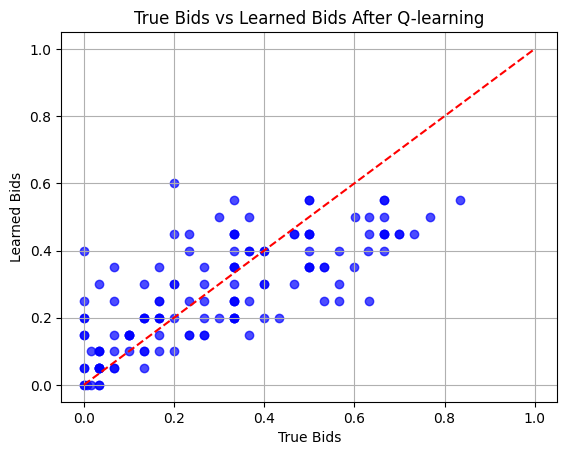

In [5]:
train_agents(agents, auction, num_rounds=100)
evaluate_agents(agents, true_bids)
